<a href="https://colab.research.google.com/github/Mahi-sinha/cyberbullying_detection/blob/main/execution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/cyberbullying-classification")

print("Path to dataset files:", path)

100%|██████████| 2.82M/2.82M [00:00<00:00, 138MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/cyberbullying-classification/versions/1


In [ ]:
import pandas as pd
data=pd.read_csv("/root/.cache/kagglehub/datasets/andrewmvd/cyberbullying-classification/versions/1/cyberbullying_tweets.csv")
data.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


checking for null values

In [ ]:
data.isnull().sum()

,0
tweet_text,0
cyberbullying_type,0


In [ ]:
if data.isnull().values.any(): #checking for null
    print("There are null values in the dataset.")
else:
    print("No null values found ")


No null values found 


checking for duplicate value

In [ ]:
data.duplicated().sum() #checking for duplicate values
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

Lowercasing

In [ ]:
data['clean_text'] = data['tweet_text'].str.lower() #lowercasing
data[['tweet_text', 'clean_text']].head()




,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...","in other words #katandandre, your food was cra..."
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is #aussietv so white? #mkr #theblock #ima...
2,@XochitlSuckkks a classy whore? Or more red ve...,@xochitlsuckkks a classy whore? or more red ve...
3,"@Jason_Gio meh. :P thanks for the heads up, b...","@jason_gio meh. :p thanks for the heads up, b..."
4,@RudhoeEnglish This is an ISIS account pretend...,@rudhoeenglish this is an isis account pretend...


Removing Punctuations

In [ ]:
import re

def remove_punctuation(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters and spaces
    return text

data['clean_text'] = data['clean_text'].apply(remove_punctuation)
data[['tweet_text', 'clean_text']].head()


,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkks a classy whore or more red velv...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thanks for the heads up but no...
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish this is an isis account pretendi...


Removing Stop Words

In [ ]:
import nltk    #removestopwords
from nltk.corpus import stopwords

# download stopword list once
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

data['clean_text'] = data['clean_text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
data[['tweet_text', 'clean_text']].head()


,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",words katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkks classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thanks heads concerned another ...
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish isis account pretending kurdish ...


Tokenization

In [ ]:
from nltk.tokenize import word_tokenize #tokenization
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

data['tokenized_text'] = data['clean_text'].apply(word_tokenize)
data[['clean_text', 'tokenized_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,clean_text,tokenized_text
0,words katandandre food crapilicious mkr,"[words, katandandre, food, crapilicious, mkr]"
1,aussietv white mkr theblock imacelebrityau tod...,"[aussietv, white, mkr, theblock, imacelebritya..."
2,xochitlsuckkks classy whore red velvet cupcakes,"[xochitlsuckkks, classy, whore, red, velvet, c..."
3,jasongio meh p thanks heads concerned another ...,"[jasongio, meh, p, thanks, heads, concerned, a..."
4,rudhoeenglish isis account pretending kurdish ...,"[rudhoeenglish, isis, account, pretending, kur..."


Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer #lemmatization
import nltk
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

data['lemmatized_text'] = data['tokenized_text'].apply(lemmatize_words)


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
data[['tokenized_text', 'lemmatized_text']].head()


,tokenized_text,lemmatized_text
0,"[words, katandandre, food, crapilicious, mkr]","[word, katandandre, food, crapilicious, mkr]"
1,"[aussietv, white, mkr, theblock, imacelebritya...","[aussietv, white, mkr, theblock, imacelebritya..."
2,"[xochitlsuckkks, classy, whore, red, velvet, c...","[xochitlsuckkks, classy, whore, red, velvet, c..."
3,"[jasongio, meh, p, thanks, heads, concerned, a...","[jasongio, meh, p, thanks, head, concerned, an..."
4,"[rudhoeenglish, isis, account, pretending, kur...","[rudhoeenglish, isi, account, pretending, kurd..."


Stemming

In [ ]:
from nltk.stem import PorterStemmer #stemming

stemmer = PorterStemmer()

def stem_words(tokens):
    return [stemmer.stem(word) for word in tokens]

data['stemmed_text'] = data['tokenized_text'].apply(stem_words)
data[['tokenized_text', 'stemmed_text']].head()

,tokenized_text,stemmed_text
0,"[words, katandandre, food, crapilicious, mkr]","[word, katandandr, food, crapilici, mkr]"
1,"[aussietv, white, mkr, theblock, imacelebritya...","[aussietv, white, mkr, theblock, imacelebritya..."
2,"[xochitlsuckkks, classy, whore, red, velvet, c...","[xochitlsuckkk, classi, whore, red, velvet, cu..."
3,"[jasongio, meh, p, thanks, heads, concerned, a...","[jasongio, meh, p, thank, head, concern, anoth..."
4,"[rudhoeenglish, isis, account, pretending, kur...","[rudhoeenglish, isi, account, pretend, kurdish..."


Removing Numbers

In [ ]:
def remove_numbers(text): #removing no.
    return re.sub(r'\d+', '', text)

data['clean_text'] = data['clean_text'].apply(remove_numbers)


In [ ]:
data[['tweet_text', 'clean_text']].head()


,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",words katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkks classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thanks heads concerned another ...
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish isis account pretending kurdish ...


In [ ]:
import unicodedata

def remove_accents(text):
    return ''.join(c for c in unicodedata.normalize('NFKD', text) if not unicodedata.combining(c))

data['clean_text'] = data['clean_text'].apply(remove_accents)


joining the text for tf/idf

In [ ]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def lemmatize_and_stem(tokens):
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    stemmed = [stemmer.stem(word) for word in lemmatized]
    return stemmed

# Apply both in order
data['final_tokens'] = data['tokenized_text'].apply(lemmatize_and_stem)

# Convert tokens back to text
data['final_text'] = data['final_tokens'].apply(lambda x: ' '.join(x))

# Optional cleanup for extra spaces
data['final_text'] = data['final_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

data[['tweet_text', 'final_text']].head()


,tweet_text,final_text
0,"In other words #katandandre, your food was cra...",word katandandr food crapilici mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkk classi whore red velvet cupcak
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thank head concern anoth angri ...
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish isi account pretend kurdish acco...


tf idf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # you can tune between 3000–10000
    ngram_range=(1, 2),     # use unigrams + bigrams (helps capture context)
    min_df=3,               # ignore very rare words
    max_df=0.9,             # ignore extremely common words
)


In [ ]:
# Apply TF-IDF on the final preprocessed text
X = tfidf.fit_transform(data['final_text'])
y = data['cyberbullying_type']   # Target labels


Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
print("TF-IDF shape:", X.shape)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


TF-IDF shape: (47656, 5000)
Training set: (33359, 5000)
Testing set: (14297, 5000)


In [ ]:
feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:30])


Sample features: ['aalwuhaib' 'ab' 'abandon' 'abil' 'abl' 'abort' 'absolut' 'abt' 'abus'
 'acc' 'accept' 'access' 'accident' 'accomplish' 'accord' 'account' 'acct'
 'accur' 'accus' 'achiev' 'acknowledg' 'across' 'act' 'act like' 'action'
 'activ' 'activist' 'actor' 'actual' 'ad']


Classifier used :-naive bayes,Svm and Random Forest

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define your three models
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f" Accuracy for {name}: {acc*100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Store results for comparison
    results[name] = acc



🔹 Training Naive Bayes ...
 Accuracy for Naive Bayes: 78.03%

Classification Report:
                     precision    recall  f1-score   support

                age       0.82      0.97      0.89      2398
          ethnicity       0.90      0.92      0.91      2388
             gender       0.88      0.79      0.83      2384
  not_cyberbullying       0.65      0.43      0.52      2381
other_cyberbullying       0.60      0.60      0.60      2347
           religion       0.78      0.97      0.87      2399

           accuracy                           0.78     14297
          macro avg       0.77      0.78      0.77     14297
       weighted avg       0.77      0.78      0.77     14297


🔹 Training SVM ...
 Accuracy for SVM: 82.46%

Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      2398
          ethnicity       0.97      0.97      0.97      2388
             gender       0.88      0.85      0

Confusion Matrix

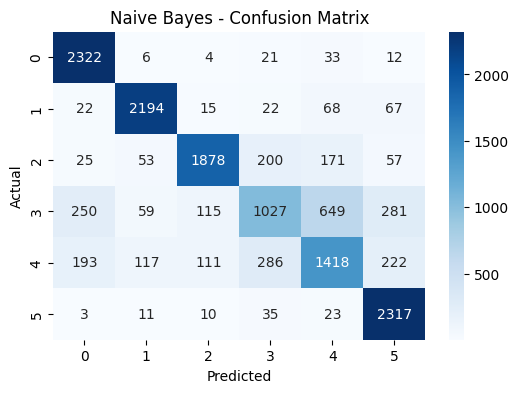

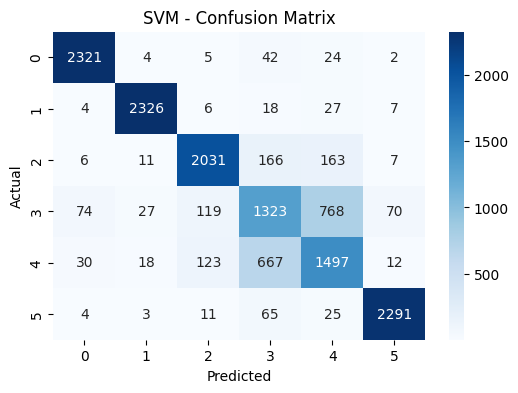

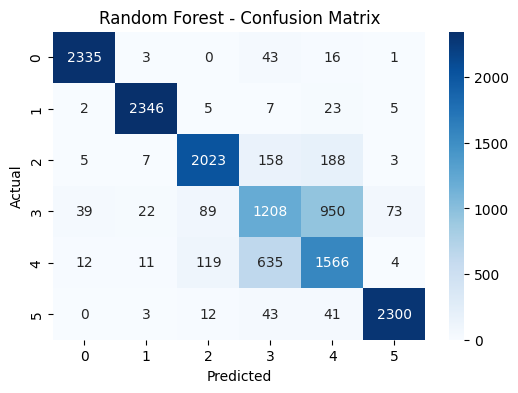

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_ if hasattr(model, "classes_") else None)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Word CLoud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:
data['cyberbullying_type'].unique()


array(['not_cyberbullying', 'gender', 'religion', 'other_cyberbullying',
       'age', 'ethnicity'], dtype=object)

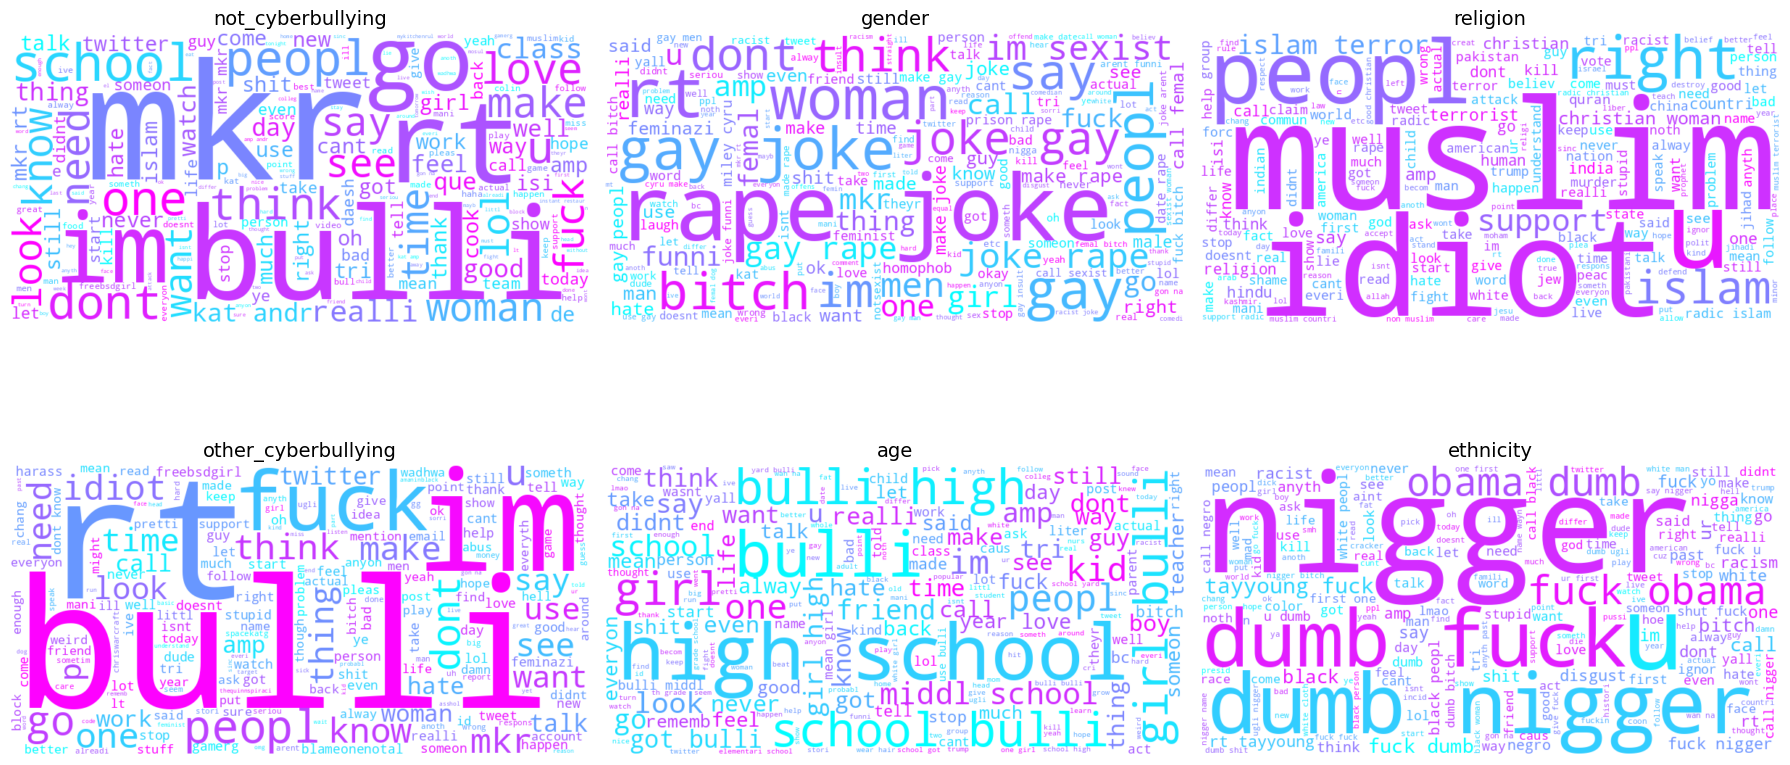

In [ ]:
# Create a figure
plt.figure(figsize=(18, 10))

# Enumerate over each category and create a WordCloud
for i, label in enumerate(data['cyberbullying_type'].unique(), 1):
    plt.subplot(2, 3, i)  # adjust grid size based on number of classes
    text = " ".join(data[data['cyberbullying_type'] == label]['final_text'])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='cool',
        max_words=200
    ).generate(text)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(label, fontsize=14)

plt.tight_layout()
plt.show()


Stacked Essemblance Meta Learner:-Logistic Regression

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define base models
base_learners = [
    ('nb', MultinomialNB()),
    ('svc', LinearSVC(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
]

# Define meta-learner
meta_learner = LogisticRegression(max_iter=1000)

# Create Stacking Classifier
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=False,  # Only base model predictions go to meta-learner
    cv=5
)

# Train stacking model
stack_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_model.predict(X_test)
print("Stacking Ensemble Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Stacking Ensemble Accuracy: 0.8446527243477653
Classification Report:
                      precision    recall  f1-score   support

                age       0.98      0.97      0.98      2398
          ethnicity       0.98      0.98      0.98      2388
             gender       0.90      0.85      0.88      2384
  not_cyberbullying       0.63      0.56      0.59      2381
other_cyberbullying       0.62      0.74      0.67      2347
           religion       0.97      0.96      0.96      2399

           accuracy                           0.84     14297
          macro avg       0.85      0.84      0.84     14297
       weighted avg       0.85      0.84      0.85     14297

